Resultat från kopplad lösare:
  Critical pressure  Pc  = 22.3548 Pa
  Destillatormynningstryck Po = 8.6795 Pa
  Pumptryck   Pp  = 8.3740 Pa
  Filmflöde   n1  = 2.766 µmol/s
  Gasflöde    n2  = 668.716 µmol/s
  Totalt      n   = 671.481 µmol/s
  Min pumphastighet S_min vid critical pressure = 75.95581183767302 l/s


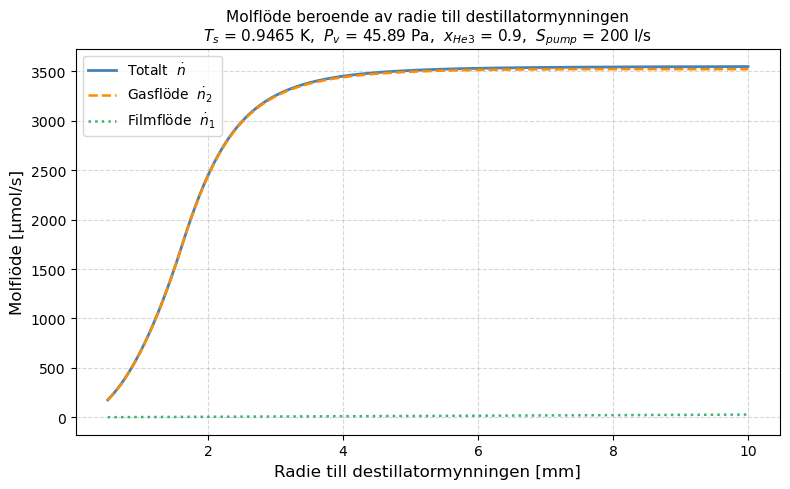

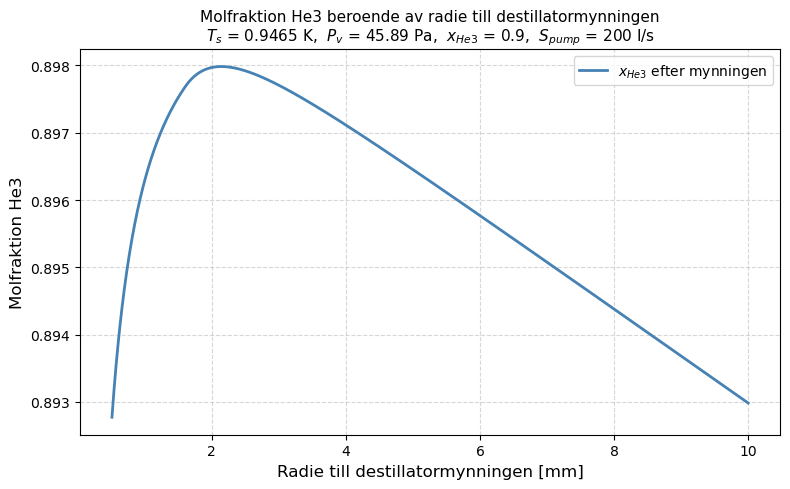

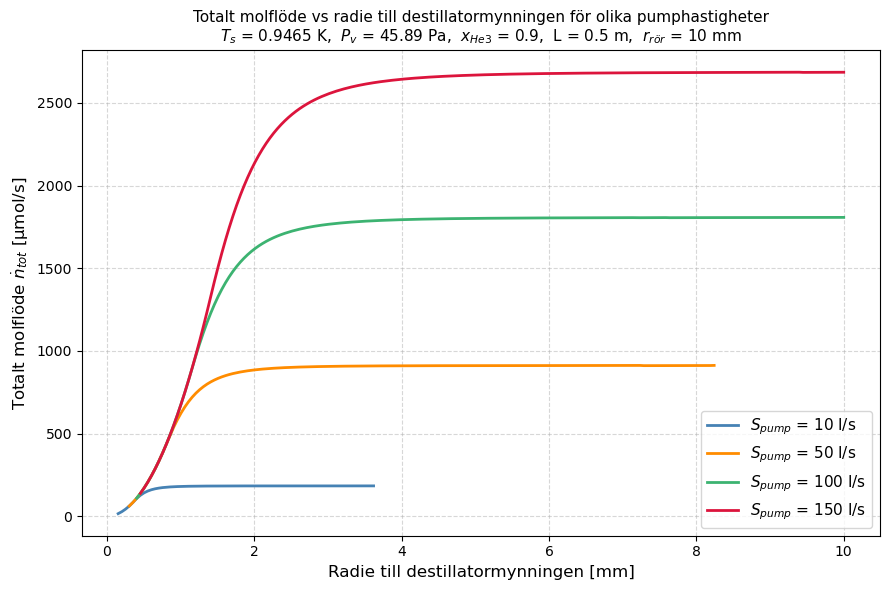

In [ ]:

import numpy as np
from scipy.optimize import brentq

# ── Konstanter ────────────────────────────────────────────────────
R0    = 8.314         # Allmänna gaskonstanten
kb    = 1.380649e-23  # Boltzmann
M3    = 3.016e-3      # molmassa He-3 [kg/mol]
M4    = 4.003e-3      # molmassa He-4 [kg/mol]
gamma = 5 / 3         # Värmekapacitet kvot
d_mol = 2.6e-10       # kinetisk diameter He-3 [m]
sigma = np.pi * d_mol**2 
eps   = 1.5e-6        # väggråghet [m]  Vald enligt Livesey 


# ════════════════════════════════════════════════════════════════
#  INDATA 
# ════════════════════════════════════════════════════════════════

# Destillatorparametrar enligt referensfallet från hela koden
Ts  = 0.9465   # K
Pv  = 45.89   # Pa
X3  = 0.9000   # He-3 fraktion i gasfasen (x_v)

# Geometri parametrar enligt referensfallet från hela koden
r_or = 1e-3  # m  orifice radie (diamter = 1 mm)
L_rör = 0.5   # m rörläng
r_rör = 10e-3  # m rörradie 

# Pump 
S_pump = 200e-3  # m³/s  Valfri parameter, kan justeras för att se hur det påverkar flödet      
T_pump = 300     # K från referensfallet i hela koden



# ════════════════════════════════════════════════════════════════
#  WANG-MODELLEN
# ════════════════════════════════════════════════════════════════

def gasflöde_orifice(Pv, Po, Ts, r, X3):
    Ms    = X3 * M3 + (1 - X3) * M4
    rho_g = Pv * Ms / (R0 * Ts) # gasdensitet vid stilltryck och temperatur enligt idealgaslagen
    cs    = np.sqrt(gamma * R0 * Ts / Ms) # ljudhastighet i gasen enligt idealgaslagen

    Pc = Pv * (2 / (gamma + 1)) ** (gamma / (gamma - 1))  # Critical pressure
    Po = max(Po, Pc)  # flödet mättas under Pc 

    prat = Po / Pv
    A    = np.pi * r**2
    n2 = A * rho_g * cs / Ms * np.sqrt(2 / (gamma - 1)) \
           * prat**(1/gamma) * np.sqrt(1 - prat**((gamma-1)/gamma))     
    return n2


def filmflöde_orifice(r):
    rho_s  = 145.0     # kg/m³
    d_film = 30e-9     # m, filmtjocklek
    d0     = 0.36e-9   # m, ett atomlager
    nu_c   = 1.23e-8 / d_film  # kritisk hastighet [m/s]
    C      = 2 * np.pi * r     # orificens omkrets [m]
    n1 = rho_s * C * nu_c * (d_film - d0) / M4 # Molflöde av filmfluiden
    return n1


# ════════════════════════════════════════════════════════════════
#  LIVESEY-MODELLEN
# ════════════════════════════════════════════════════════════════

def viskositet(T):
    """He-3 gasviskositet [Pa·s], kinetisk teori (statisktisk mekanik)."""
    m = M3 / 6.022e23
    return 2 * np.sqrt(m * kb * T) / (3 * sigma * np.sqrt(np.pi))   #https://en.wikipedia.org/wiki/Kinetic_theory_of_gases


def molekylär_konduktans(T, L, r):
    """Molekylär konduktans för cylindrisk kanal [m³/s], Livesey kap 4."""
    le    = L * (1 + 1 / (3 + 3*L / (7*r)))
    alpha = 1 / (1 + 3*le / (8*r))
    Ca    = np.pi * r**2 * np.sqrt(R0*T / M3) / np.sqrt(2*np.pi)
    return Ca * alpha


# Liknande implementation av Liveseys modell som i hela koden men anpassad för två givna tryck i rörets ändar, med iterativ lösning för Re och choked flow. 
def livesey_flöde(Pu, Pd, T, L, r, n_c=0):
    
    D  = 2 * r          # hydraulisk diameter
    Lc = L + 0.41 * D   # effektiv längd (Livesey s. 2)
    K  = Pu / max(Pd, 1e-30)
    eta = viskositet(T)
    Cz  = np.pi * r**2 * np.sqrt(R0 * T / M3)   # hjälpterm (Livesey s. 2)
    Cd  = np.pi * r**4 / (8 * eta * L)           # Poiseuille-konduktans

    # Knudsen-korrektionsfunktion φ(Kn), Livesey kap 2
    lam = kb * T / (np.sqrt(2) * sigma * max((Pu+Pd)/2, 1e-30))
    Kn  = lam / D
    phi_s = 3*np.pi / (128*Kn)
    phi_l = 3*np.pi * (1 + 4*Kn) / (128 * (1 + Kn) * Kn**0.55)
    Phi   = phi_s + (phi_l - phi_s) * L / (L + D)

    Qm = molekylär_konduktans(T, L, r) * (Pu - Pd)

    # Viskös komponent med Re-iteration
    Re = 0.0 # Första gissning, kommer att uppdateras iterativt
    Qv = 0.0 # Första gissning, kommer att uppdateras iterativt
    for _ in range(400):
        Re_old = Re

        # Darcy-friktionsfaktor (Livesey Eq. 7)
        if Re <= 2300:
            fd = 64 / max(Re, 1e-8)
        elif Re >= 3500:
            fd = 1.6364 / np.log(6.9/Re + (eps/(3.7*D))**1.11)**2
        else:
            f_lam  = 64 / Re
            f_turb = 1.6364 / np.log(6.9/Re + (eps/(3.7*D))**1.11)**2
            fd = np.interp(Re, [2300, 3500], [f_lam, f_turb])

        hf = n_c + fd * Lc / D

        # Lågtryckskriterium (Livesey sek. 3.3, BC med kända tryck)
        low_flow = (L/D) > np.sqrt(np.pi/2) * (K-1) / max(3.2*Kn, 1e-20)

        if low_flow or Re < 2300:
            # Laminärt lågflöde, Eq. 8
            inner = (Cz/Cd)**2 + (n_c+1) * (K**2 - 1)
            Qv = Cz * Pd / (n_c+1) * (np.sqrt(max(inner, 0)) - Cz/Cd)  

        else:
            # Termodynamisk lösning (Mach-tal), Livesey kap 3.2
            def choked_eq(Man):
                log_arg = (1/Man)**2 * ((gamma-1)*Man**2 + 2) / ((gamma-1) + 2)
                return (1/gamma) * (1/Man**2 - 1 - (gamma+1)/2 * np.log(max(log_arg, 1e-30))) - hf #Ma_x = 1

            try:
                Man_c = brentq(choked_eq, 1e-10, 1 - 1e-10, xtol=1e-12) # Mach-tal vid choked flow
                Kc = (1/Man_c) * np.sqrt((gamma+1)/2)* (1 + (gamma-1)/2 * Man_c**2) ** ((gamma+1)/(2*(gamma-1)))

                if K >= Kc:  # choked
                    Qv = np.sqrt(gamma*(gamma+1)/2) * Cz * Pu / Kc
                else:        # ej choked – lös Eq. 2 för unchoked Man
                    def unchoked_eq(Man): #Hitta Mach-tal för unchoked flow
                        term = 2*(gamma-1)*(K*Man)**2 \
                               / (1 + (gamma-1)/2*Man**2)**((gamma+1)/(gamma-1))      
                        Max2 = (np.sqrt(1 + term) - 1) / (gamma - 1)       # sek 3.2 i Livesey, lös för Max^2
                        if Max2 <= 0: return 1e10     # undvik komplexa tal/negativ rot
                        Max = np.sqrt(Max2)
                        log_arg = (Max/Man)**2 * ((gamma-1)*Man**2+2) \
                                  / ((gamma-1)*Max**2+2)
                        return (1/gamma) * (1/Man**2 - 1/Max**2
                                - (gamma+1)/2 * np.log(max(log_arg, 1e-30))) - hf

                    Man_u = brentq(unchoked_eq, 1e-10, 1 - 1e-10, xtol=1e-12) # Mach-tal för unchoked flow
                    Qv = np.sqrt(gamma) * Cz * Pu * Man_u \
                         / (1 + 0.5*(gamma-1)*Man_u**2) ** ((gamma+1)/(2*(gamma-1)))

            except Exception:
                # Fallback om Mach-lösningen misslyckas
                Qv = Cz * Pd * np.sqrt((K**2-1) / max(n_c + 1 + fd*Lc/D, 1e-10))

        # Uppdatera Re (Livesey Eq. 6)
        Re = 4 * M3 * Qv / max(R0 * T * 2*np.pi*r * eta, 1e-40)
        if abs(Re - Re_old) < 0.5: # Kör tills Re konvergerar och Re och Re_old är typ samma
            break

    Q_tot = Qv + Qm / (1 + Phi)
    Re_tot = 4 * M3 * Q_tot / max(R0 * T * 2*np.pi*r * eta, 1e-40) # max för att undvika division med noll, finns på flera ställen i koden
    return Q_tot, Kn, Re_tot


# ════════════════════════════════════════════════════════════════
#  KOPPLAD LÖSARE
# ════════════════════════════════════════════════════════════════

def lös_still_till_pump(Pv, Ts, X3, r_or, L_rör, r_rör, S_pump, T_pump, n_c=0):
 
    n1 = filmflöde_orifice(r_or)

    def residual(Po):
        n2    = gasflöde_orifice(Pv, Po, Ts, r_or, X3)
        n_tot = n1 + n2 
        Pp    = n_tot * R0 * T_pump / S_pump 
        Q_orifice  = n_tot * R0 * Ts
        Q_live, _, _ = livesey_flöde(Po, Pp, Ts, L_rör, r_rör, n_c)
        return Q_live - Q_orifice  # Flödet ut ur mynningen bör bli samma som flödet som Livesey beräknar för att pumpen ska kunna hantera det

    Pc    = Pv * (2/(gamma+1))**(gamma/(gamma-1))
    Po_lo = max(Pc * 0.1, Pv * 1e-6) # undre gräns för Po (minst 10% av Pc eller mycket lågt) Gissningsintervall för Brentq
    Po_hi = Pv * 0.9999              # övre gräns för Po (nästan lika med Pv)


    Po = brentq(residual, Po_lo, Po_hi, rtol=1e-6)

    n2    = gasflöde_orifice(Pv, Po, Ts, r_or, X3)
    n_tot = n1 + n2
    Pp    = n_tot * R0 * T_pump / S_pump
    _, Kn, Re = livesey_flöde(Po, Pp, Ts, L_rör, r_rör, n_c)

    return dict(Po=Po, Pp=Pp, n_tot=n_tot, n1=n1, n2=n2, Kn=Kn, Re=Re, Pc=Pc)


def S_pump_critical(Pv, Ts, X3, r_or, L_rör, r_rör, T_pump, n_c=0):
    """
    Beräknar minsta pumphastighet [m³/s] för att uppnå critical pressure vid orificen.
    """
    Pc    = Pv * (2 / (gamma + 1)) ** (gamma / (gamma - 1))
    n1    = filmflöde_orifice(r_or)
    n2    = gasflöde_orifice(Pv, Pc, Ts, r_or, X3)   # flöde vid Po = Pc
    n_tot = n1 + n2

    # Livesey: hitta S_pump så att ledningen klarar n_tot vid Po=Pc → Pp
    # Q_livesey(Pc → Pp) = n_tot · R0 · Ts  →  lös för Pp och sedan S_pump = n_tot · R0 · T_pump / Pp
    Q_orifice = n_tot * R0 * Ts

    def residual(Pp):
        Q_live, _, _ = livesey_flöde(Pc, Pp, Ts, L_rör, r_rör, n_c)
        return Q_live - Q_orifice

    Pp_sol = brentq(residual, Pc * 1e-6, Pc * 0.9999, rtol=1e-6)
    S_min  = n_tot * R0 * T_pump / Pp_sol

    
    return S_min



# Kör lösaren
res = lös_still_till_pump(Pv, Ts, X3, r_or, L_rör, r_rör, S_pump, T_pump)

# Resultat
print("Resultat från kopplad lösare:")
print(f"  Critical pressure  Pc  = {res['Pc']:.4f} Pa")
print(f"  Destillatormynningstryck Po = {res['Po']:.4f} Pa")
print(f"  Pumptryck   Pp  = {res['Pp']:.4f} Pa")
print(f"  Filmflöde   n1  = {res['n1']*1e6:.3f} µmol/s")
print(f"  Gasflöde    n2  = {res['n2']*1e6:.3f} µmol/s")
print(f"  Totalt      n   = {res['n_tot']*1e6:.3f} µmol/s")


S_min = S_pump_critical(Pv, Ts, X3, r_or, L_rör, r_rör, T_pump)
print(f"  Min pumphastighet S_min vid critical pressure = {S_min*1000} l/s")



# Plotta resusltaten
import matplotlib.pyplot as plt


def plotta_radie_vs_molarflöde(
    Pv, Ts, X3, L_rör, r_rör, S_pump, T_pump,
    r_min=0.1e-3, r_max=1.5e-3, n_punkter=80, n_c=0
):
    radier = np.linspace(r_min, r_max, n_punkter)
    n1_vals, n2_vals, n_tot_vals = [], [], []

    for r in radier:
        try:
            res = lös_still_till_pump(Pv, Ts, X3, r, L_rör, r_rör, S_pump, T_pump, n_c)
            n1_vals.append(res['n1'] * 1e6)
            n2_vals.append(res['n2'] * 1e6)
            n_tot_vals.append(res['n_tot'] * 1e6)
        except Exception:
            n1_vals.append(np.nan)
            n2_vals.append(np.nan)         # Om koden kraschar vid vissa radier, fyll på med NaN för att bibehålla array-längden
            n_tot_vals.append(np.nan)

    r_mm = radier * 1e3
    n1_vals    = np.array(n1_vals)
    n2_vals    = np.array(n2_vals)
    n_tot_vals = np.array(n_tot_vals)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(r_mm, n_tot_vals, color='steelblue',     linewidth=2,   label='Totalt  $\\dot{n}$')
    ax.plot(r_mm, n2_vals,    color='darkorange',    linewidth=1.8, linestyle='--', label='Gasflöde  $\\dot{n}_2$')
    ax.plot(r_mm, n1_vals,    color='mediumseagreen', linewidth=1.8, linestyle=':',  label='Filmflöde  $\\dot{n}_1$')

    ax.set_xlabel('Radie till destillatormynningen [mm]', fontsize=12)
    ax.set_ylabel('Molflöde [µmol/s]', fontsize=12)
    ax.set_title(
        f'Molflöde beroende av radie till destillatormynningen\n'
        f'$T_s$ = {Ts} K,  $P_v$ = {Pv} Pa,  $x_{{He3}}$ = {X3},  '
        f'$S_{{pump}}$ = {S_pump*1e3:.0f} l/s',
        fontsize=11
    )
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()
    plt.show()
    return r_mm, n1_vals, n2_vals, n_tot_vals


def plotta_radie_vs_koncentration(
    Pv, Ts, X3, L_rör, r_rör, S_pump, T_pump,
    r_min=0.1e-3, r_max=1.5e-3, n_punkter=80, n_c=0
):
    radier = np.linspace(r_min, r_max, n_punkter)
    n1_vals, n2_vals, n_tot_vals = [], [], []

    for r in radier:
        try:
            res = lös_still_till_pump(Pv, Ts, X3, r, L_rör, r_rör, S_pump, T_pump, n_c)
            n1_vals.append(res['n1'] * 1e6)
            n2_vals.append(res['n2'] * 1e6)
            n_tot_vals.append(res['n_tot'] * 1e6)
        except Exception:
            n1_vals.append(np.nan)                    # Om koden kraschar vid vissa radier, fyll på med NaN för att bibehålla array-längden
            n2_vals.append(np.nan)
            n_tot_vals.append(np.nan)

    r_mm = radier * 1e3
    n1_vals    = np.array(n1_vals)
    n2_vals    = np.array(n2_vals)
    n_tot_vals = np.array(n_tot_vals)

    x3 = X3 * n2_vals / (n1_vals + n2_vals)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(r_mm, x3, color='steelblue', linewidth=2, label='$x_{He3}$ efter mynningen')

    ax.set_xlabel('Radie till destillatormynningen [mm]', fontsize=12)
    ax.set_ylabel('Molfraktion He3', fontsize=12)
    ax.set_title(
        f'Molfraktion He3 beroende av radie till destillatormynningen\n'
        f'$T_s$ = {Ts} K,  $P_v$ = {Pv} Pa,  $x_{{He3}}$ = {X3},  '
        f'$S_{{pump}}$ = {S_pump*1e3:.0f} l/s',
        fontsize=11
    )
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()
    plt.show()
    return r_mm, n1_vals, n2_vals, n_tot_vals


def plotta_radie_vs_molarflöde_flera_pumpar(
    Pv, Ts, X3, L_rör, r_rör, T_pump,
    S_pump_lista=[10e-3, 50e-3, 100e-3, 150e-3],
    r_min=0.0005e-3, r_max=10.0e-3, n_punkter=200, n_c=0
):
    """
    Plottar totalt molflöde som funktion av orifice-radie
    för flera olika pumphastigheter S_pump.
    """
    radier = np.linspace(r_min, r_max, n_punkter)
    färger = ['steelblue', 'darkorange', 'mediumseagreen', 'crimson']

    fig, ax = plt.subplots(figsize=(9, 6))

    for S_pump, färg in zip(S_pump_lista, färger):
        n_tot_vals = []

        for r in radier:
            try:
                res = lös_still_till_pump(Pv, Ts, X3, r, L_rör, r_rör, S_pump, T_pump, n_c)
                n_tot_vals.append(res['n_tot'] * 1e6)
            except Exception:
                n_tot_vals.append(np.nan)          # Om koden kraschar vid vissa radier, fyll på med NaN för att bibehålla array-längden

        ax.plot(
            radier * 1e3,
            n_tot_vals,
            color=färg,
            linewidth=2,
            label=f'$S_{{pump}}$ = {S_pump*1e3:.0f} l/s'
        )

    ax.set_xlabel('Radie till destillatormynningen [mm]', fontsize=12)
    ax.set_ylabel('Totalt molflöde $\\dot{n}_{tot}$ [µmol/s]', fontsize=12)
    ax.set_title(
        f'Totalt molflöde vs radie till destillatormynningen för olika pumphastigheter\n'
        f'$T_s$ = {Ts} K,  $P_v$ = {Pv} Pa,  $x_{{He3}}$ = {X3},  '
        f'L = {L_rör} m,  $r_{{rör}}$ = {r_rör*1e3:.0f} mm',
        fontsize=11
    )
    ax.legend(fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()
    plt.show()


# Anropa plottar
plotta_radie_vs_molarflöde(
    Pv, Ts, X3, L_rör, r_rör, S_pump, T_pump,
    r_min=0.0005e-3, r_max=10.0e-3, n_punkter=1000
)

plotta_radie_vs_koncentration(
    Pv, Ts, X3, L_rör, r_rör, S_pump, T_pump,
    r_min=0.0005e-3, r_max=10.0e-3, n_punkter=1000
)


plotta_radie_vs_molarflöde_flera_pumpar(
    Pv, Ts, X3, L_rör, r_rör, T_pump,
    S_pump_lista=[10e-3, 50e-3, 100e-3, 150e-3],
    r_min=0.0005e-3, r_max=10.0e-3, n_punkter=200
)